# HELD iron examples

This notebook runs the unified `HELD.py` workflow on one Fe example for each phase: `bcc`, `fcc`, and `hcp`.

- Aggregation: `mean`
- Initial MD frames skipped: `100`
- Each section writes a HELD CSV, a mean dispersion plot, and one HELD heat map


In [2]:
!pip install spglib


  Using cached spglib-2.7.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (4.2 kB)
Using cached spglib-2.7.0-cp312-cp312-macosx_11_0_arm64.whl (911 kB)


In [3]:
from pathlib import Path
import sys

from IPython.display import Image, display


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "HELD.py").exists() and (candidate / "held").exists():
            return candidate
    raise RuntimeError("Could not find the HELD project root from the current working directory.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from HELD import fit_case, plot_heatmap, plot_mean_dispersion


DATASETS = {
    "bcc": Path("/Users/dajuarez4/Documents/Fe/dataset/bcc/non-mag/2.43_5000K.npz"),
    "fcc": Path("/Users/dajuarez4/Documents/Fe/dataset/fcc/non-mag/3.00_5000K.npz"),
    "hcp": Path("/Users/dajuarez4/Documents/Fe/dataset/hcp/a_2.18_c_3.42_5000K.npz"),
}

OUTPUT_ROOT = PROJECT_ROOT / "examples" / "iron"
SKIP = 100
POINTS_PER_SEGMENT = 60
Y_BINS = 600


def run_case(phase: str, npz_path: Path):
    out_dir = OUTPUT_ROOT / phase
    out_dir.mkdir(parents=True, exist_ok=True)

    held_csv = out_dir / "held_mean_skip100.csv"
    disp_dat = out_dir / "held_dispersion_skip100_mean.dat"
    disp_png = out_dir / "held_dispersion_skip100_mean.png"
    heat_cache = out_dir / "held_heatmap_steps_skip100.npz"
    heat_png = out_dir / "held_heatmap_skip100_mean.png"

    result, info = fit_case(
        phase=phase,
        npz_path=npz_path,
        output_csv=held_csv,
        aggregate="mean",
        skip=SKIP,
    )
    dispersion = plot_mean_dispersion(
        phase=phase,
        npz_path=npz_path,
        held_csv=held_csv,
        output_data=disp_dat,
        output_plot=disp_png,
        points_per_segment=POINTS_PER_SEGMENT,
    )
    heatmap = plot_heatmap(
        phase=phase,
        npz_path=npz_path,
        held_csv=held_csv,
        cache_npz=heat_cache,
        output_plot=heat_png,
        points_per_segment=POINTS_PER_SEGMENT,
        y_bins=Y_BINS,
    )

    print(f"phase={phase} symbol={info['symbol']} frames={info['n_frames']} shells={info['num_shells']}")
    print("shell distances (A):", ", ".join(f"{value:.6f}" for value in info["selected_shell_distances"]))
    print("dispersion range (THz):", float(dispersion["held_thz"].min()), float(dispersion["held_thz"].max()))
    print("heatmap q-points:", int(heatmap["step_frequencies_thz"].shape[1]))
    display(Image(filename=str(disp_png)))
    display(Image(filename=str(heat_png)))

    return {
        "fit": result,
        "info": info,
        "dispersion": dispersion,
        "heatmap": heatmap,
        "paths": {
            "csv": held_csv,
            "dispersion_data": disp_dat,
            "dispersion_plot": disp_png,
            "heatmap_cache": heat_cache,
            "heatmap_plot": heat_png,
        },
    }


PROJECT_ROOT


PosixPath('/Users/dajuarez4/Documents/Fe/HELD')

## BCC Fe example

phase=bcc symbol=Fe frames=299 shells=5
shell distances (A): 2.104442, 2.430000, 3.436539, 4.029699, 4.208884
dispersion range (THz): 1.0984772498164182e-07 17.120972343926574
heatmap q-points: 301


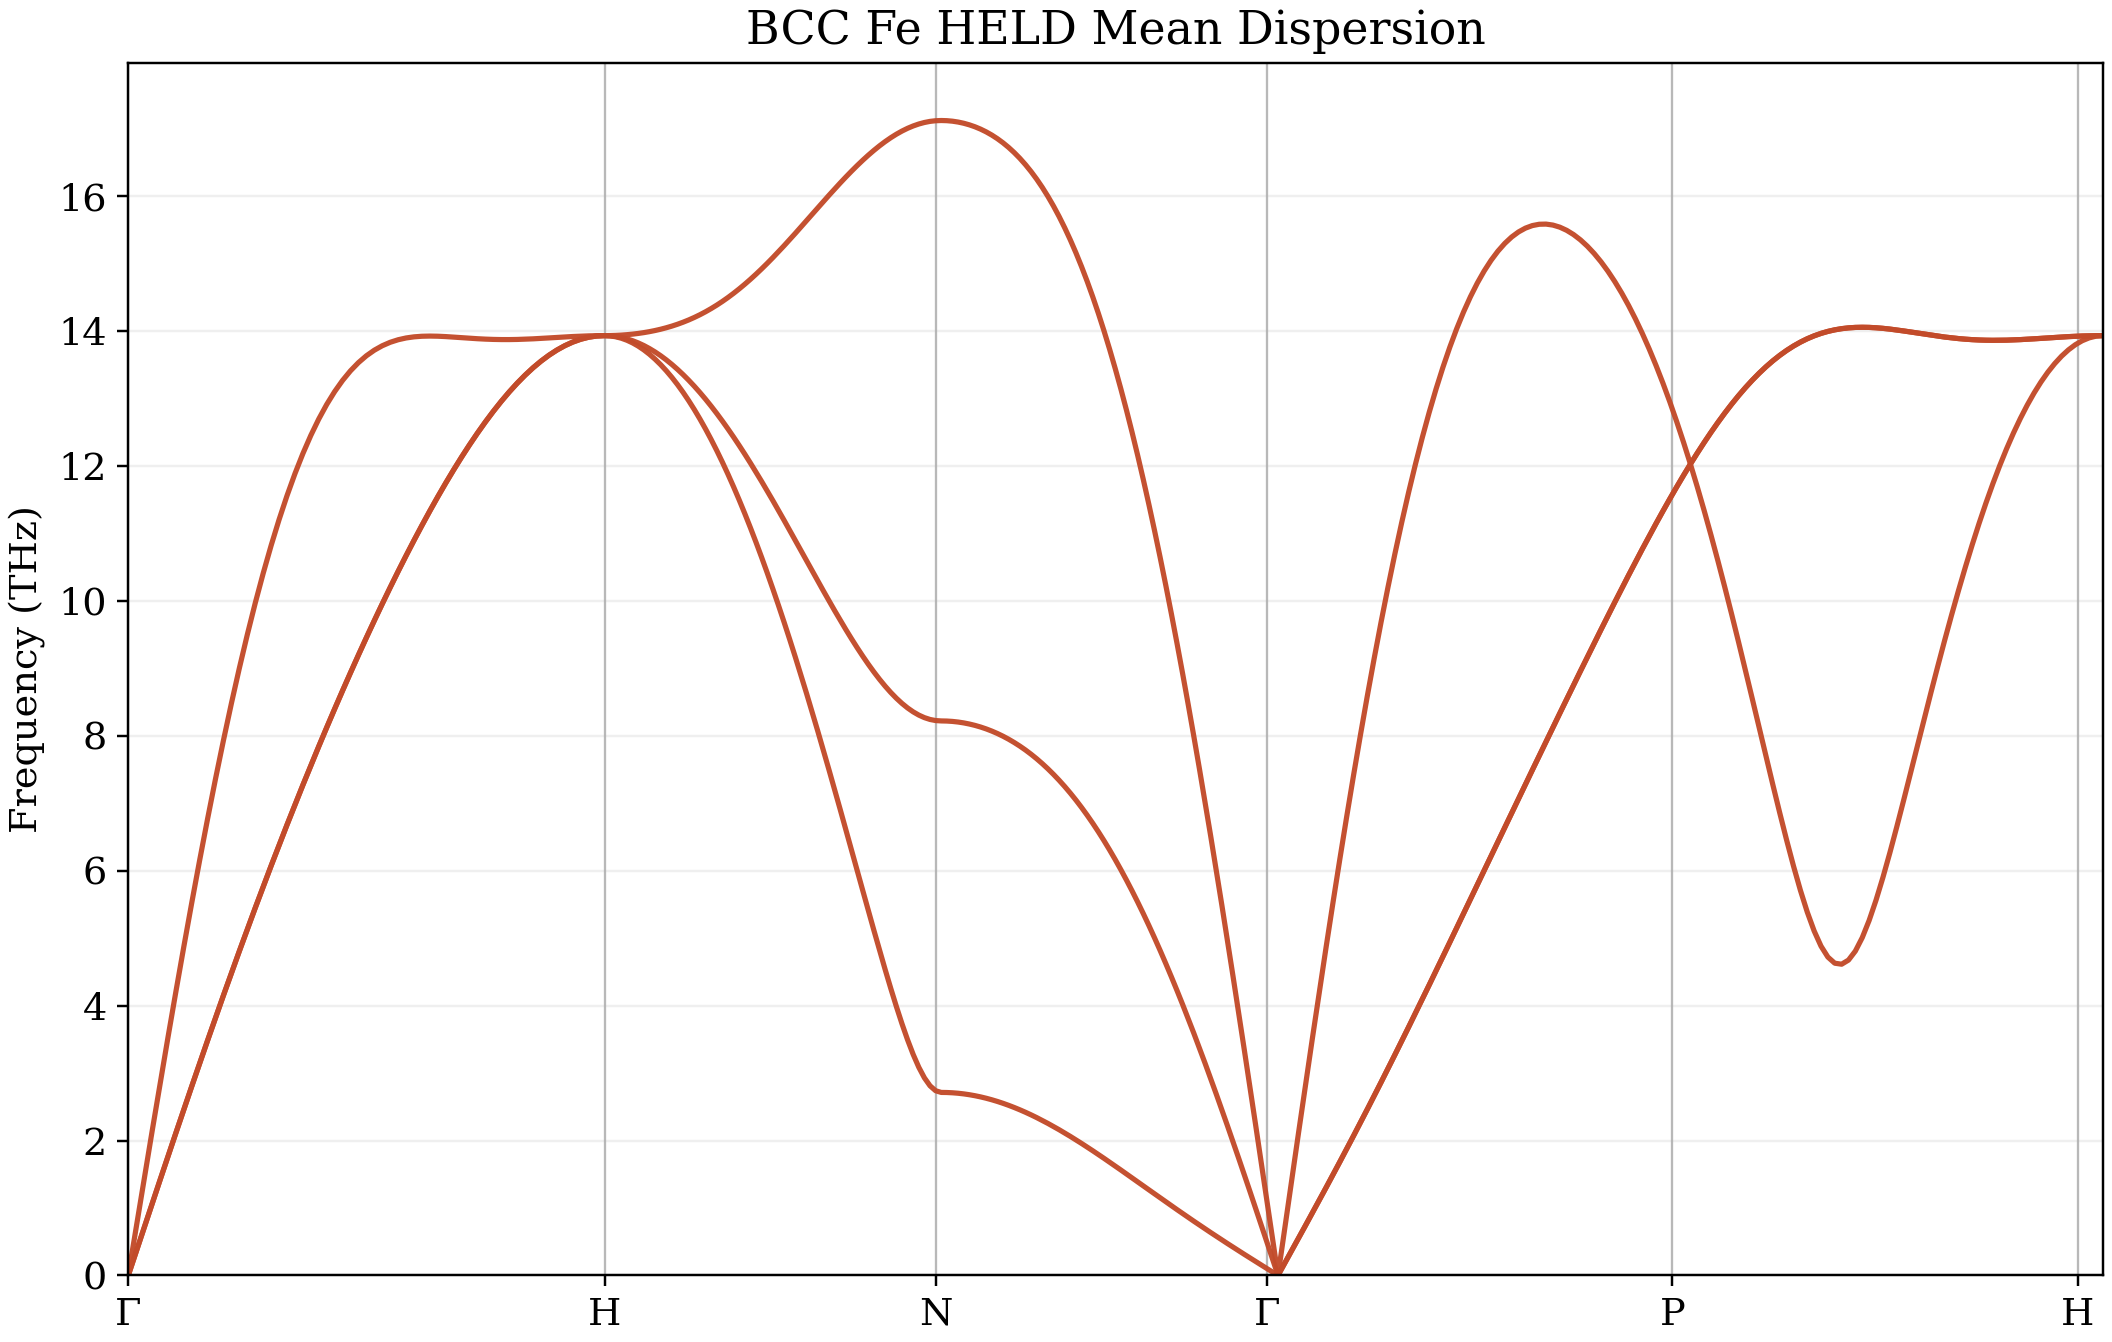

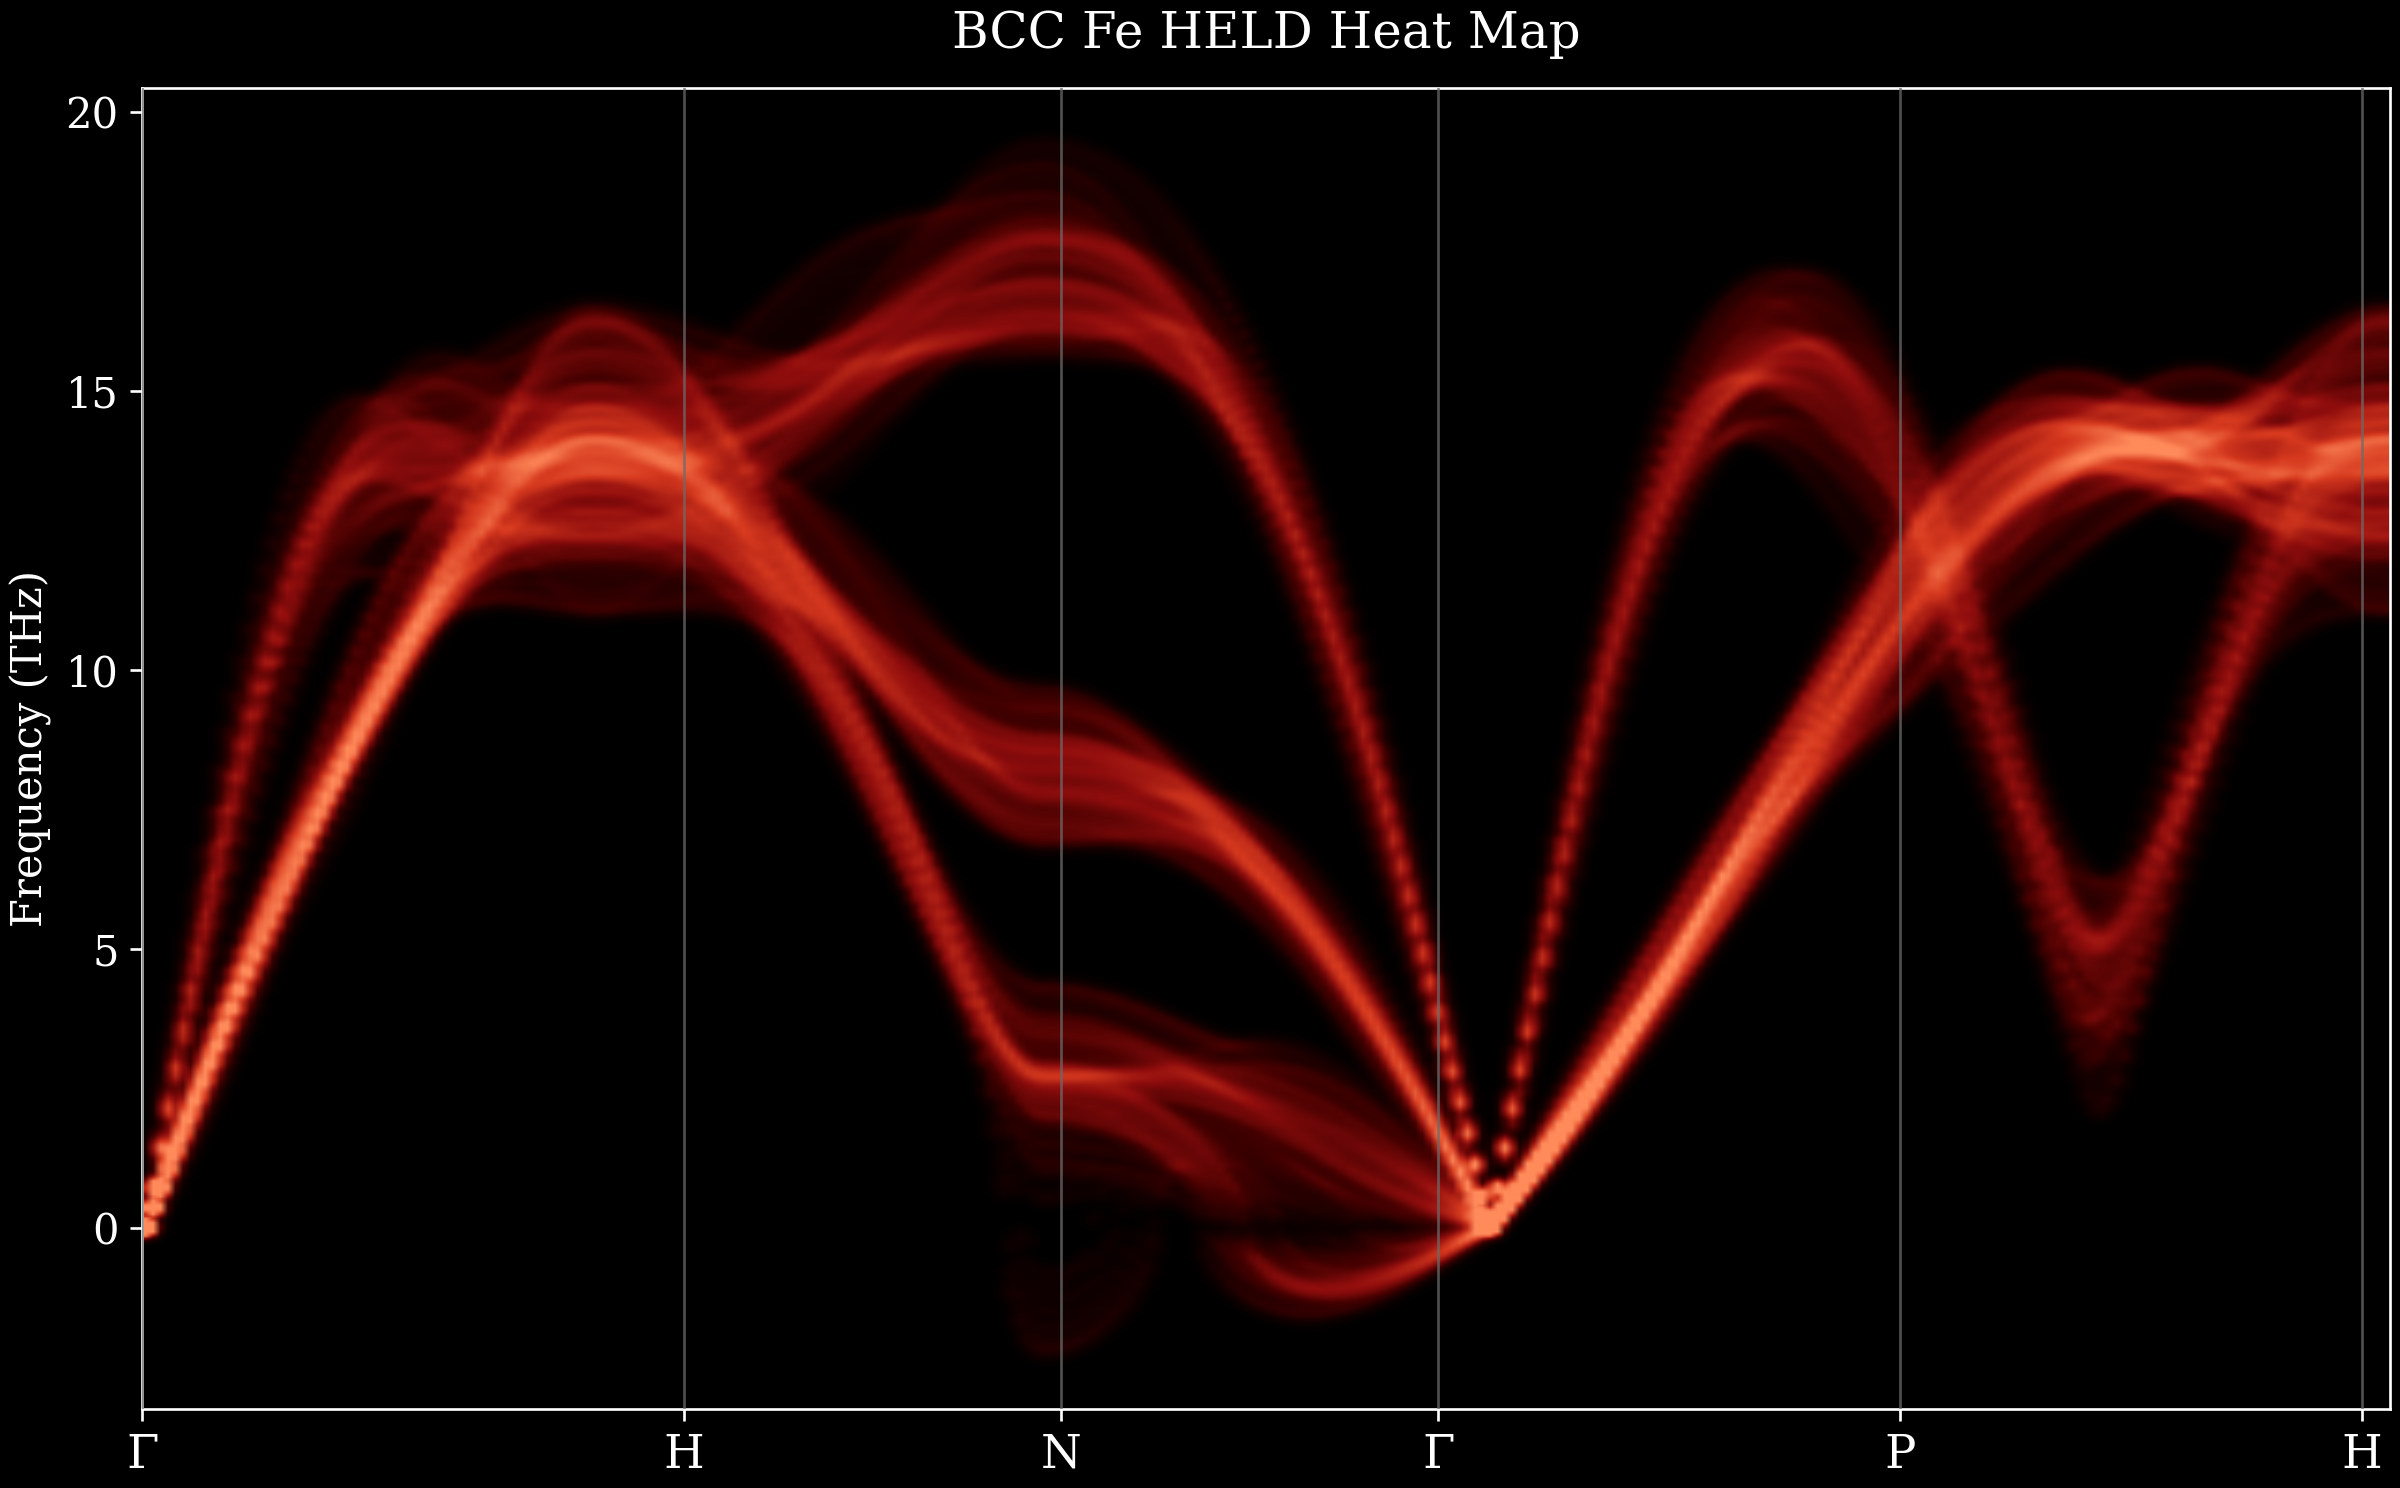

In [4]:
bcc_case = run_case("bcc", DATASETS["bcc"])

## FCC Fe example

phase=fcc symbol=Fe frames=299 shells=5
shell distances (A): 2.121320, 3.000000, 3.674235, 4.242641, 4.743416
dispersion range (THz): -1.9440197212466295e-07 22.59180543714026
heatmap q-points: 301


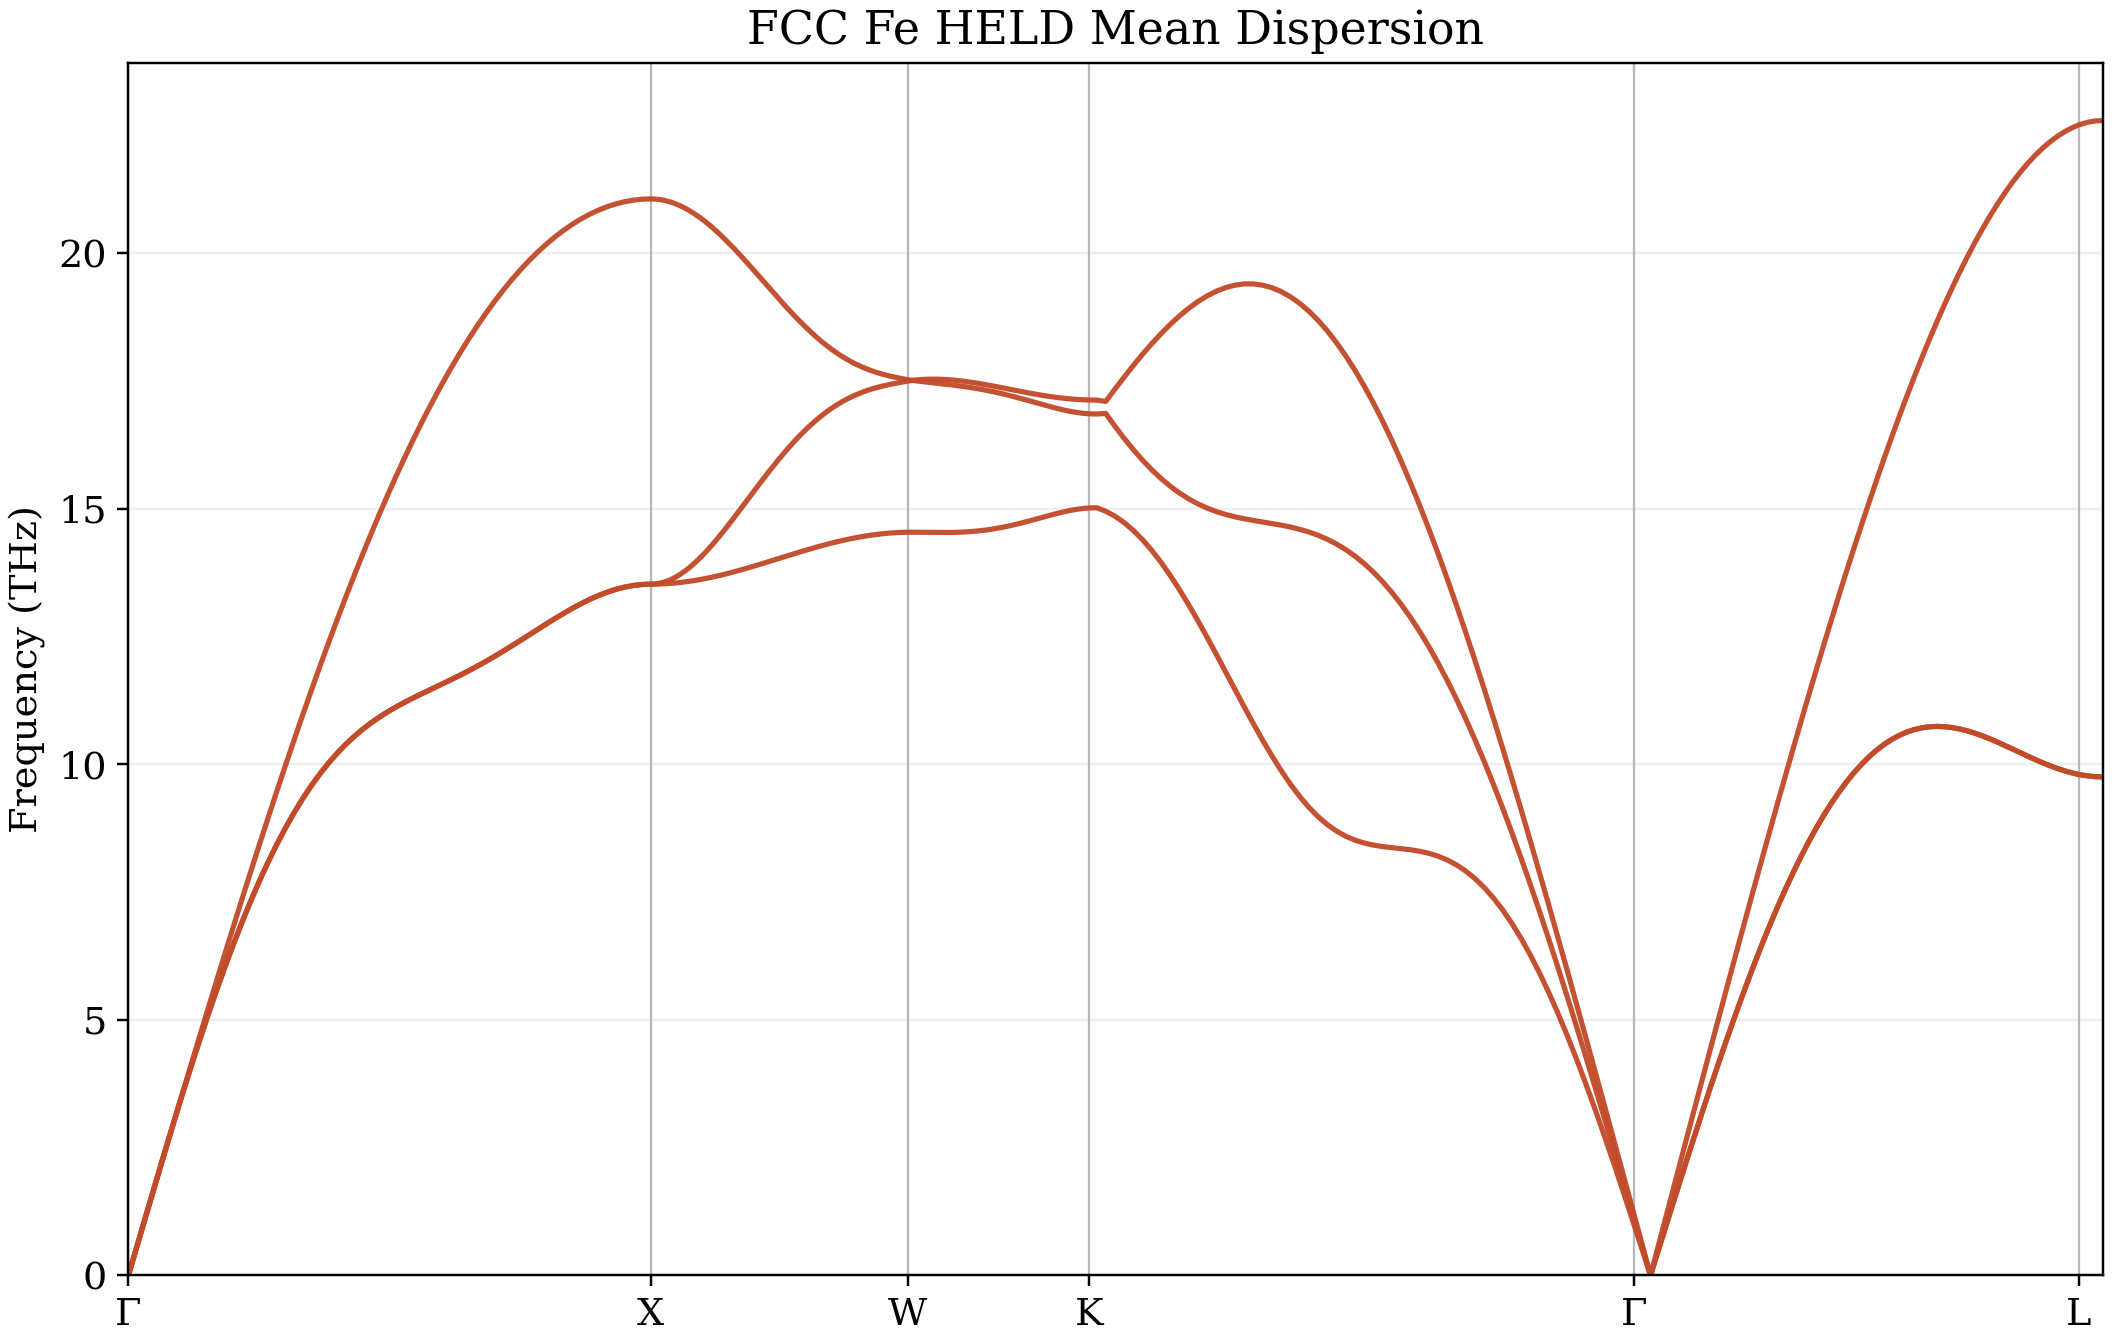

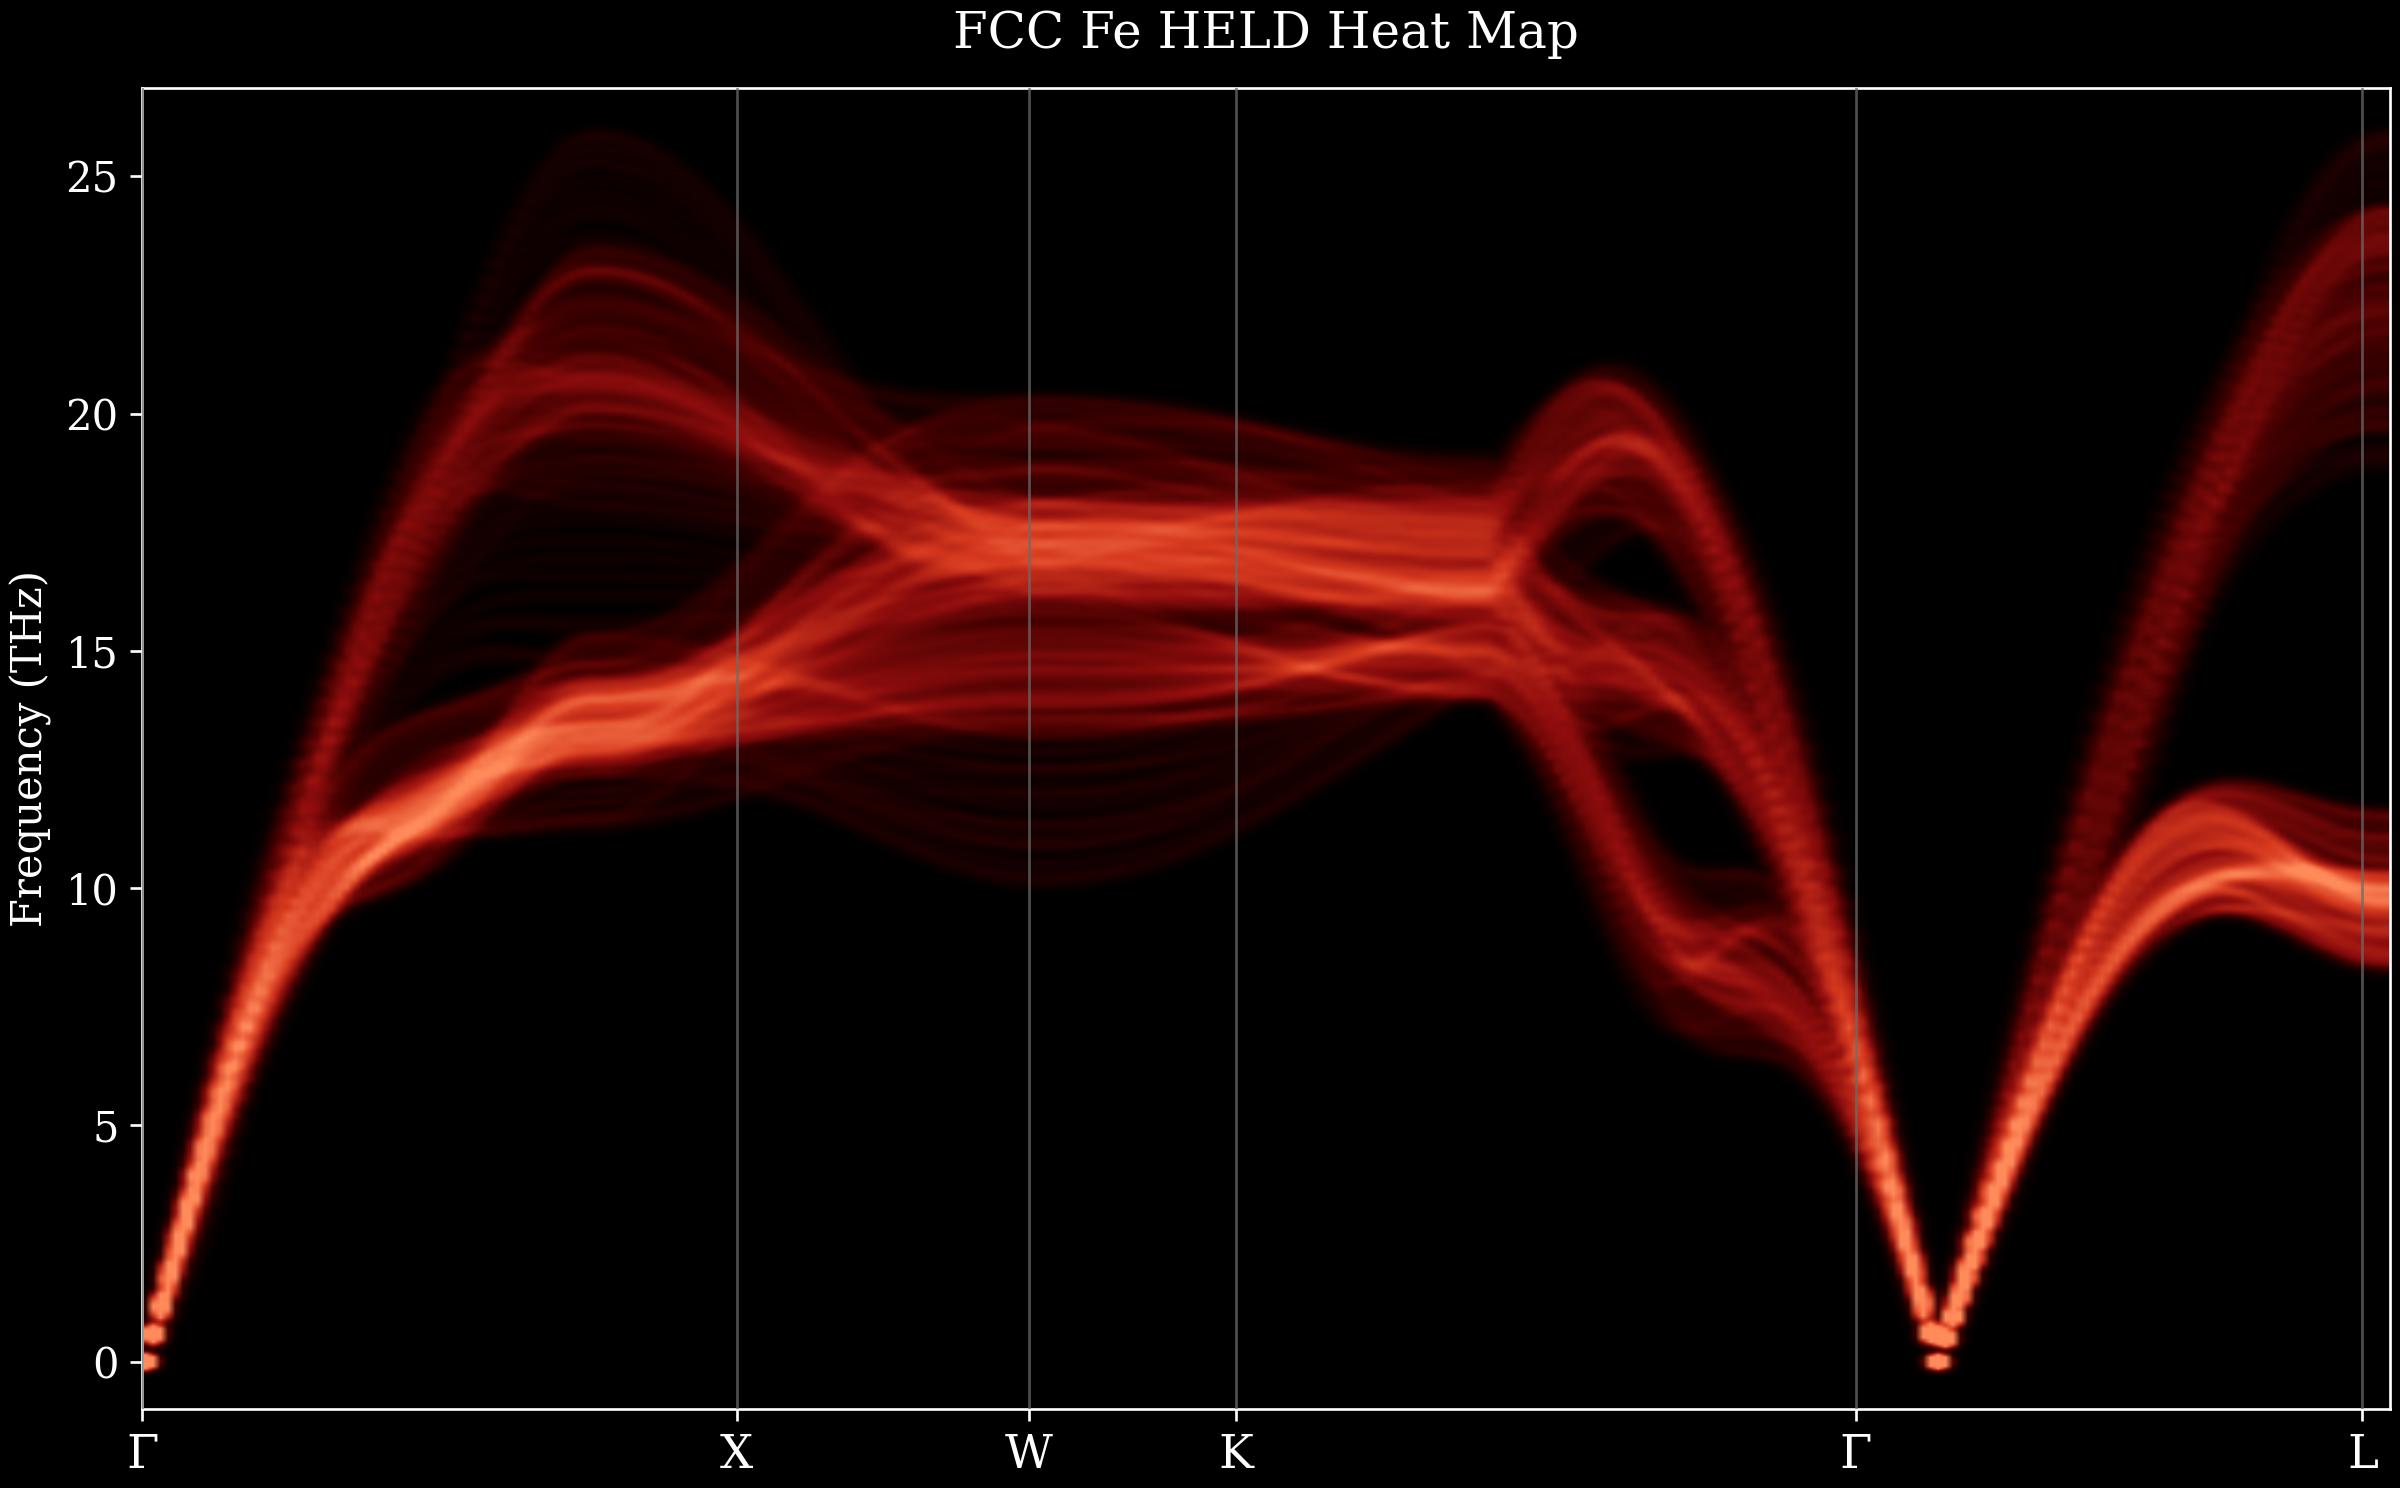

In [5]:
fcc_case = run_case("fcc", DATASETS["fcc"])


## HCP Fe example

phase=hcp symbol=Fe frames=299 shells=4
shell distances (A): 1.857995, 2.180000, 2.244165, 2.573016
dispersion range (THz): -1.9175289388193551e-07 18.874054223409708
heatmap q-points: 421


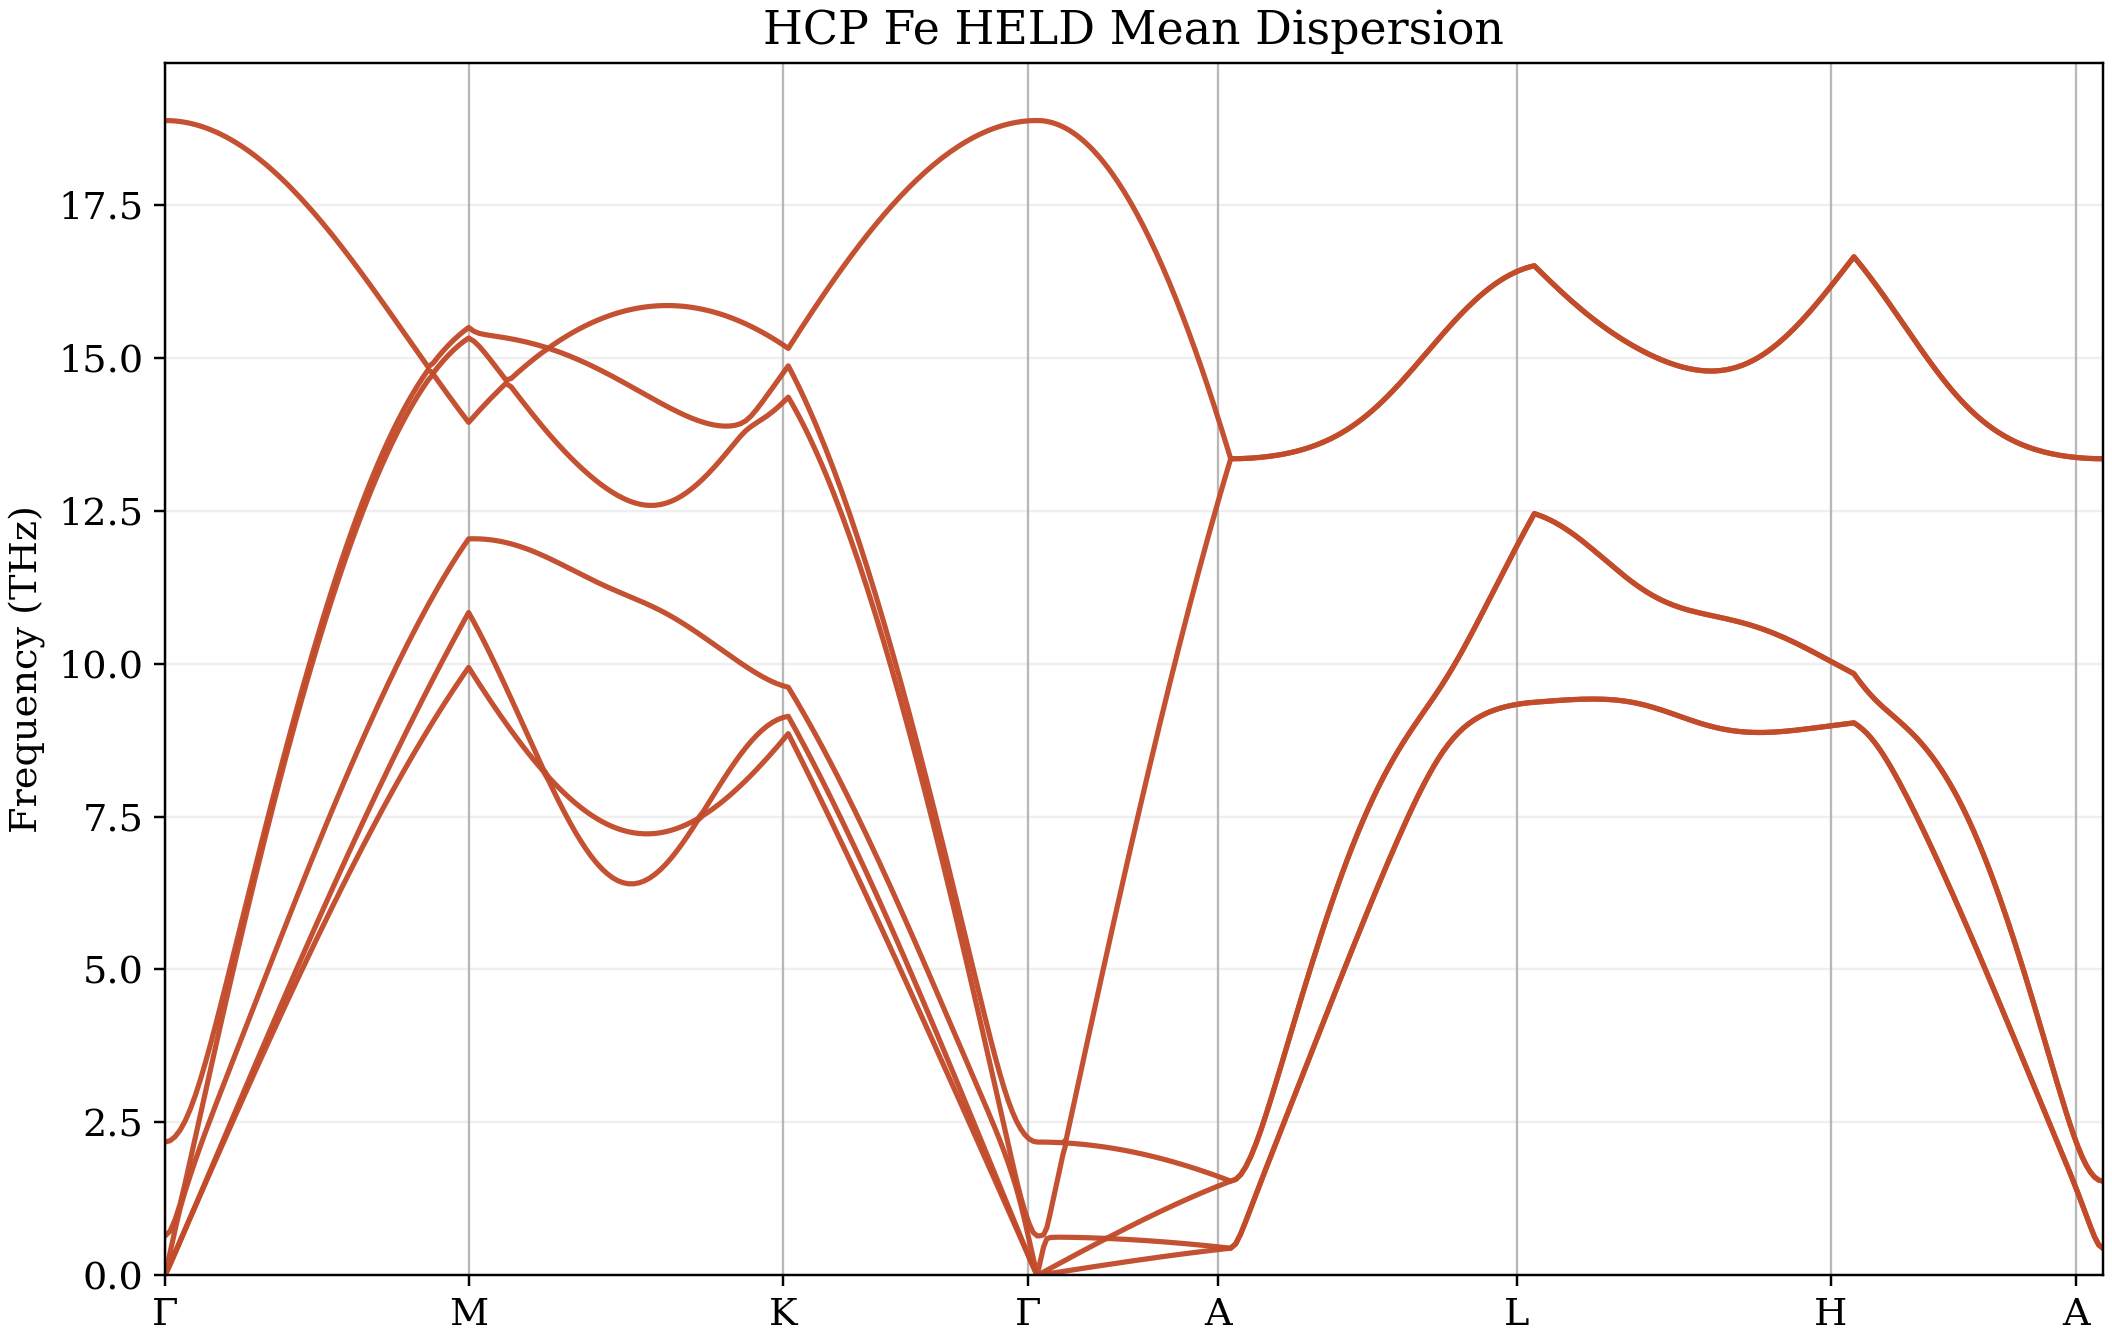

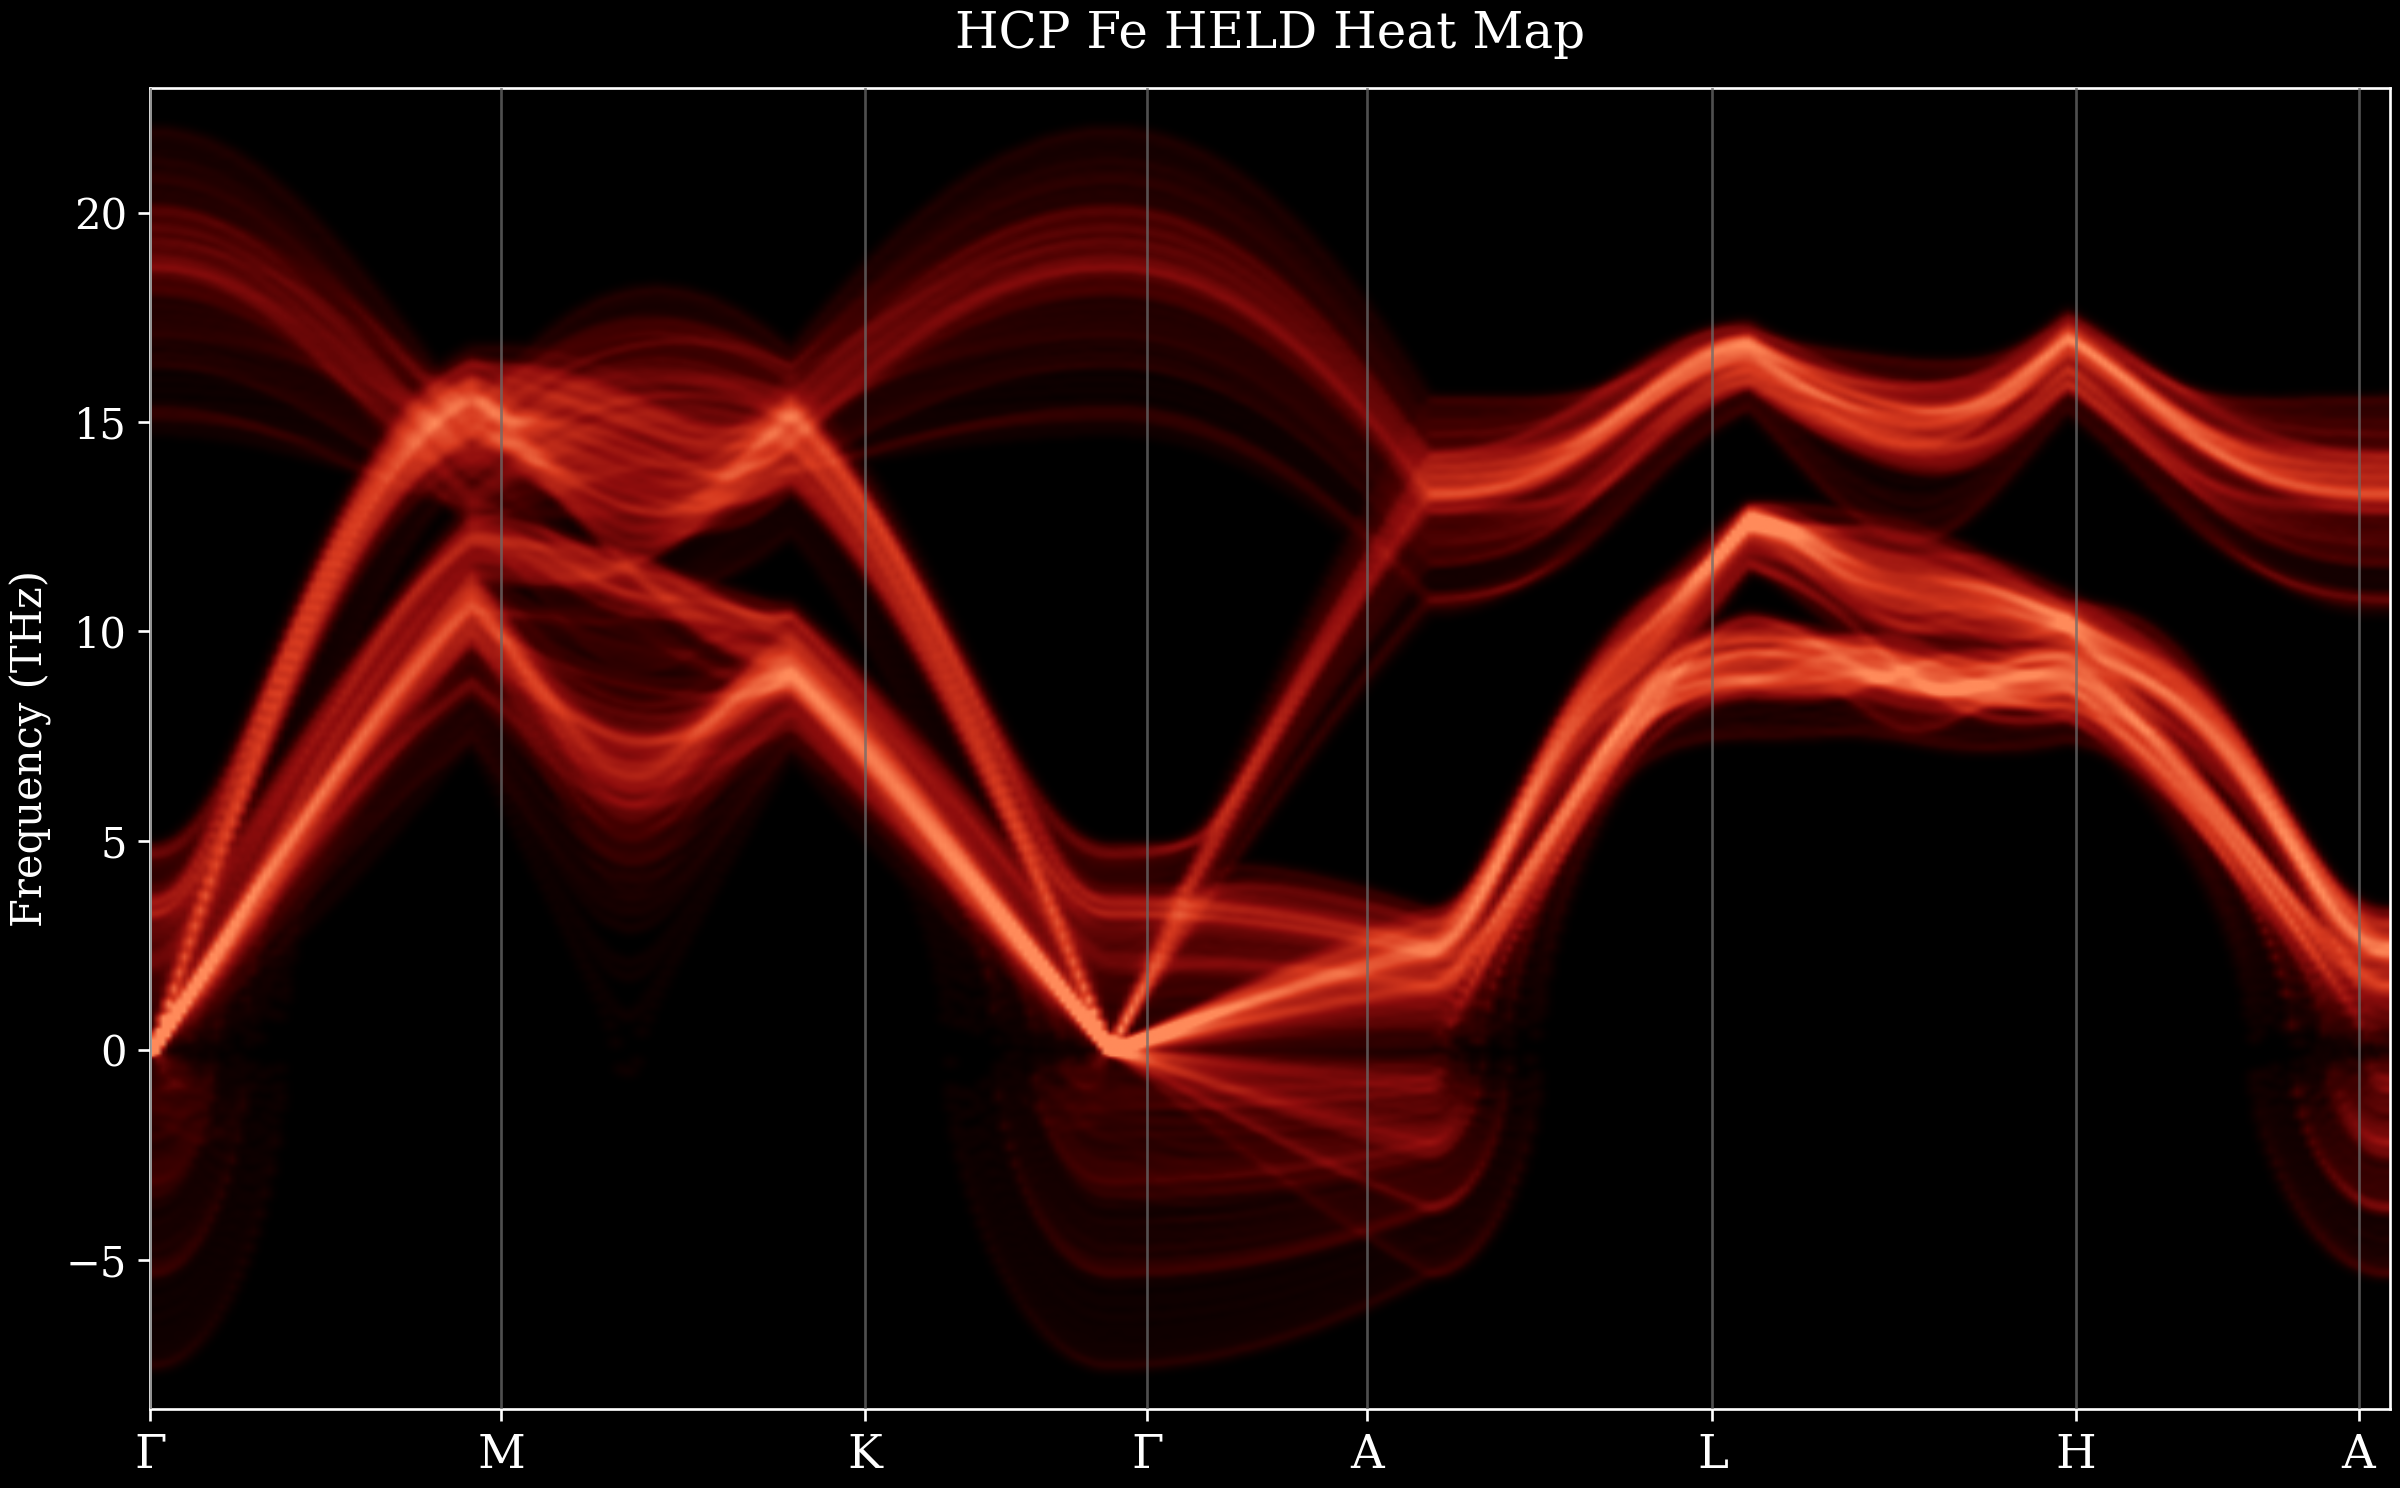

In [6]:
hcp_case = run_case("hcp", DATASETS["hcp"])
